# Geospatial Data Science - EEPS 440/460

# Lecture 19

# Random Forests

---

# Reading:

## Motivation
### A data-driven method of traffic emissions mapping with land use random forest models:
https://www.sciencedirect.com/science/article/pii/S0306261921012289

---

# Outline

* Resampling methods
* Bagging
* Random forests

# Resampling Methods

**Rationale**: Interest in repeatedly drawing samples from a training set and refitting a model
of interest on each sample in order to obtain additional information about
the fitted model. 

Source: G. James et al., An Introduction to Statistical Learning

# Motivation: Assessing test error rate

**Training error rate**: Average error that results when using a statistical learning method (e.g., decision tree) to predict observations that were used to fit the model.

**Test error rate**: Average error that results when using a statistical learning method (e.g., decision tree) to predict observations that were not used to fit the model.

Note that these two can be ***very*** different.

# Show by example: Revisit Iris species example

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import sklearn.datasets
iris = sklearn.datasets.load_iris()
#Features space
X = iris.data
y = iris.target
# Plot the data
plt.figure(figsize=(12,6))
im = plt.scatter(X[:,2],X[:,3],c=y,s=50,cmap=plt.cm.Set1,edgecolor='k')
plt.xlabel('Petal length',fontsize=20)
plt.ylabel('Petal width',fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

In [1]:
import numpy as np
import sklearn.tree
#Features space
X = iris.data[:,2:4]
#Observed classes
y = iris.target
#Feature names
feature_names = iris.feature_names[2:4]
#Define the indices from which to draw samples to define the training dataset
np.random.seed(1)
nsamples = 10
# Let's draw nsamples from our entire dataset
idx = np.random.choice(y.size,nsamples,replace=False)
# Lets create a boolean mask to select the training dataset
m = np.zeros(y.size).astype(int)
m[idx] = 1
m = m.astype(np.bool)
#Divide into training and validation
Xt = X[m,:]  # Training predictions
yt = y[m]    # Training target 
Xv = X[~m,:] # Validation predictions
yv = y[~m]   # Validation target
#Decision tree
clf = sklearn.tree.DecisionTreeClassifier(random_state=1)
#Fit the tree
clf = clf.fit(Xt,yt)
#Determine the accuracy when using the training dataset
print('Training dataset: %f' % clf.score(Xt,yt))
#Determine the accuracy when using the test dataset
print('Test data: %f' % clf.score(Xv,yv))

NameError: name 'iris' is not defined

# Cross validation 

Class of methods that estimate the test error rate by holding out a subset of the training observations from the fitting process, and then applying the statistical learning method to those held out observations.

* Validation set approach
* Leave-One-Out Cross-Validation
* k-Fold Cross-Validation

# Option 1: Validation set approach

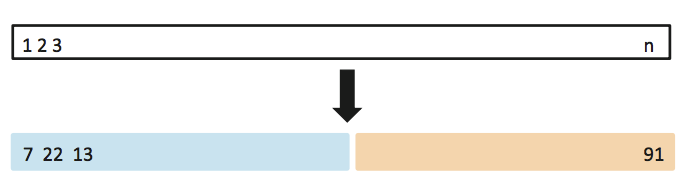

The validation set approach involves randomly dividing the available set of observations into two parts, a training set and a validation set or hold-out set. The model is fit on the training set, and the fitted model is used to predict the responses for the observations in the validation set. 

*This is what I have been doing mostly throughout this course*

# Drawbacks?

* The validation estimate of the test error rate strongly depends on the the observations that are contained within the training set and which are included in the validation set.

* Statisical methods tend to perform better when trained on more observations. By taking out data for a testing dataset, we are effectively increasing the overall error that would be possible if we used all the data. 

# Validation set approach example

In [ ]:
#Define function that samples, fits a decision tree, and evaluate the decision tree
def sample_fit_evaluate():
    #Define the indices from which to draw samples to define the training dataset
    nsamples = 10
    idx = np.random.choice(y.size,nsamples,replace=False)
    m = np.zeros(y.size).astype(int)
    m[idx] = 1
    m = m.astype(np.bool)
    #Divide into training and validation
    Xt = X[m,:]
    yt = y[m]
    Xv = X[~m,:]
    yv = y[~m]
    #Decision tree
    clf = sklearn.tree.DecisionTreeClassifier(random_state=1)
    #Fit the tree with the training set 
    clf = clf.fit(Xt,yt)
    #Return the validation accuracy score
    return clf.score(Xv,yv)
#Iterate through 100 different random validation sets
scores = [0]
for i in range(100):
    scores.append(sample_fit_evaluate())
print('Average accuracy: %f' % np.mean(scores))
#Plot the histogram of accuracy scores
plt.figure(figsize=(20,10))
plt.xticks(fontsize=25)
plt.xlabel('Accuracy',fontsize=35)
plt.yticks(fontsize=25)
plt.ylabel('Density',fontsize=35)
plt.hist(scores,density=True)
plt.show()

# In defense of the validation set approach...

It has its issues but it still is one of the only true ways to define an independent test dataset.

# Option 2: Leave-One-Out Cross Validation (LOOCV)

The dataset is split into two sets, one is a single observation which is used as the validation set and the other is composed of the rest of the observation which are used as the training set.

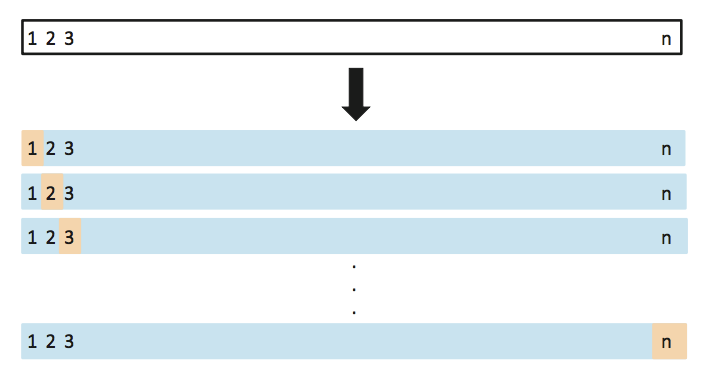

The model is fit and evaluated for every possible split of the observation dataset (i.e., number of fits is the same as the total number of observations). The average performance of all fitted trees provides the test error rate.

# Drawbacks?

* When the observation dataset is large, running a complete LOOCV can be fairly computationally expensive (sometimes). 

# LOOCV example

In [ ]:
#Define function that samples, fits a decision tree, and evaluate the decision tree
def sample_fit_evaluate(idx):
    #Define the validation value
    m = np.zeros(y.size).astype(int)
    m[idx] = 1
    m = m.astype(np.bool)
    #Divide into training and validation
    Xt = X[~m,:]
    yt = y[~m]
    Xv = X[m,:]
    yv = y[m]
    #Decision tree
    clf = sklearn.tree.DecisionTreeClassifier(random_state=1)
    #Fit the tree
    clf = clf.fit(Xt,yt)
    #Return the accuracy score
    return clf.score(Xv,yv)
#Iterate through 100 different random validation sets and leave each element out
scores = []
for i in range(y.size):
    scores.append(sample_fit_evaluate(i))
print('Average accuracy: %f' % np.mean(scores))


# Option 3: k-Fold Cross-Validation

This approach involves randomly dividing the set of observations into k groups, or folds, of approximately equal size. The first fold is treated as a validation set, and the method is fit on the remaining k − 1 folds.

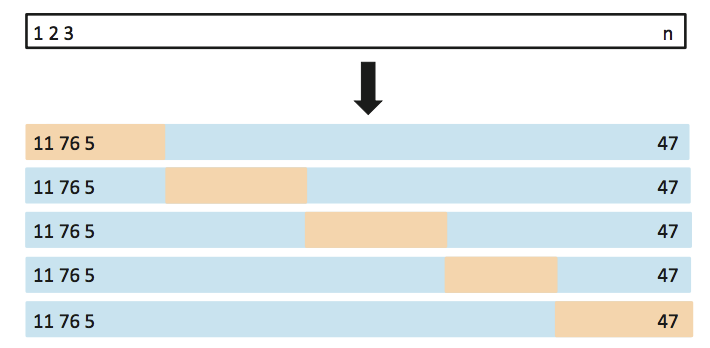

LOOCV is a special case of k-fold cross validation where k = n.

# k-Fold Cross-Validation example

In [ ]:
#Define function that samples, fits a decision tree, and evaluate the decision tree
def sample_fit_evaluate(idx):
    #Define validation subset
    m = np.zeros(y.size).astype(int)
    m[idx] = 1
    m = m.astype(np.bool)
    #Divide into training and validation
    Xt = X[~m,:]
    yt = y[~m]
    Xv = X[m,:]
    yv = y[m]
    #Decision tree
    clf = sklearn.tree.DecisionTreeClassifier()
    #Fit the tree
    clf = clf.fit(Xt,yt)
    #Return the accuracy score
    return clf.score(Xv,yv)
#Perform k cross validation
k = 10
# kfold size
k_size = int(y.size/k)
#Define the indices
idx = np.arange(y.size)
#Extract the datasets
idx_fold = []
for i in range(k):
    idx_fold.append(idx[i::k_size])
#Iterate through each fold
scores = []
for i in range(k):
    scores.append(sample_fit_evaluate(idx_fold[i]))
print('Average accuracy: %f' % np.mean(scores))

# K-fold cross validation tends to be the ''go-to'' cross validation method.

# Sklearn makes everything easier...

In [ ]:
import sklearn.model_selection
clf = sklearn.tree.DecisionTreeClassifier()
scores = sklearn.model_selection.cross_val_score(clf,X,y,cv=10)
print(np.mean(scores))

* Cross-validation gives insight into the role that sub-sampling of the data can have on the results

* All these approaches assume sampling without replacement, what if we drop this assumption?

# Bootstrap

The bootstrap is a statistical tool that is often used to quantify the uncertainty associated with a given estimator or statistical learning method. It involves any test or metric that relies on random sampling with replacement.

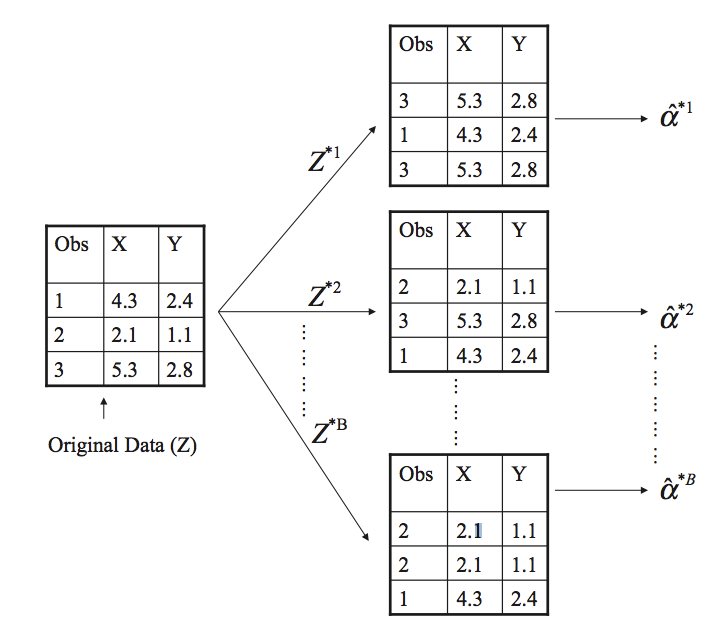

# Application of bootstrap: Uncertainty quantification

In [ ]:
#Define a univariate Gaussian
mu = 0.0
var = 1.0
#Sample 1000 elements from the distribution
sample = np.random.normal(mu,var,1000)

In [ ]:
#Estimate the mean
print(np.mean(sample))

How can we quantify the uncertainty of our estimate? Bootstrap!

In [ ]:
mus = []
nbs = 1000
for i in range(nbs):
    bsample = np.random.choice(sample,1000,replace=True)
    mus.append(np.mean(bsample))
plt.hist(mus)
plt.show()

This type of uncertainty quantification is key when we can't sample from the distribution indefinitely

# But why should I care?

As we will see, the concept of sampling with replacement (i.e., bootstrapping) is going to be key to creating ensembles of decision trees that are able to improve on the results of single decision trees.

# Let's go back to decision trees

# Reminder: Error bias vs error variance tradeoff 

* The bias error is an error from erroneous assumptions in the learning algorithm. High bias can cause an algorithm to miss the relevant relations between features and target outputs (underfitting).

* The variance is an error from sensitivity to small fluctuations in the training set. High variance can cause an  algorithm to model the random noise in the training data, rather than the intended outputs (overfitting).

* Decision trees generally have low bias but high variance.

Source: https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff

# So what can we do?

* One way is for many decision trees to provide an estimate and then figure out the majority vote.

* This is known as an "ensemble method". It maintains the advantage of low error bias and also substantially decreases the error variance. 

# Ensembles of decision trees

* **Key**: The decision trees need to be as different as possible to arrive at a global optima. 

* Ensemble approaches won't work if we just keep feeding it nearly identical decision trees.

* We need an approach that enables us to build a multitude of decision trees from the same dataset while maintaining the low bias advantage of decision trees.

# Option #1: Use different training sets

* Bootstrap!
* Create m different samples using bootstrapping and fit a decision tree to each sample
* Aggregate the results and perform a majority vote for each prediction
* This can get confusing, so let's illustrate it via a graph

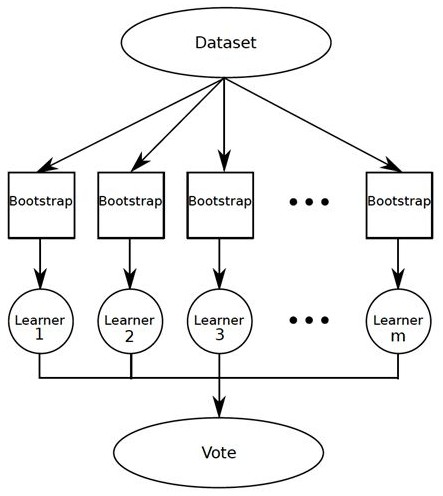

# Another perspective

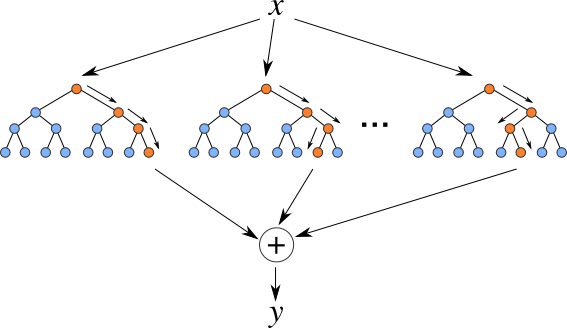

# Let's show this method from scratch

In [ ]:
#Create a function that creates an ensemble of decision trees via bootstrapping
def fit_ensemble_decision_trees(nbs,X,y):
    clfs = []
    #Let's fit nbs different decision trees
    for i in range(nbs):
        #Sample with replacement (bootstrap!)
        np.random.seed(i)
        idx = np.random.choice(y.size,y.size,replace=True)
        #Create Xt and Yt
        Xt = X[idx,:]
        yt = y[idx]
        #Decision tree
        clf = sklearn.tree.DecisionTreeClassifier()
        #Fit the tree
        clf.fit(Xt,yt)
        #Add the tree to the list
        clfs.append(clf)
    #Return the nbs fitted trees (ensemble of trees)
    return clfs

In [ ]:
#Define function to perform k-fold cross validation on the ensemble of decision trees
def kfold_cv(X,y,k,k_size,nbs):
    #Shuffle the indices
    idx = np.arange(y.size)
    #Extract the datasets
    idx_fold = []
    for i in range(k):
        idx_fold.append(idx[i::k_size])
    #Iterate through each fold
    scores = []
    for i in range(k):
        # Define validation subset
        idx = idx_fold[i]
        # create boolean mask
        m = np.zeros(y.size).astype(int)
        m[idx] = 1
        m = m.astype(np.bool)
        #Divide into training and validation
        Xt = X[~m,:]
        yt = y[~m]
        Xv = X[m,:]
        yv = y[m]
        #Fit the decision trees with the training set
        clfs = fit_ensemble_decision_trees(nbs,Xt,yt)
        #Aggregate the probabilities of obtaining a given class at each index on the validation set
        for i in range(len(clfs)):
            if i == 0:
                probs = clfs[i].predict_proba(Xv)
            else:
                probs += clfs[i].predict_proba(Xv)
        #Normalize probabilities
        probs = probs/np.sum(probs,axis=1)[:,np.newaxis]
        #Perform a majority vote by selecting the class with the highest probability
        ypred = np.argmax(probs,axis=1)
        #Evaluate
        score = np.sum(ypred == yv)/yv.size
        #Add score to the list
        scores.append(score)
    #Return the accuracy scores
    return scores

#Define number of boostrap samples
nbs = 100
#Define the number of folds for the k-fold cross validation
k = 10
# kfold size
k_size = int(y.size/k)
#Perform kfold cross validation
scores = kfold_cv(X,y,k,k_size,nbs)
#Evaluate the clfs with the test dataset
print('Average accuracy: %f' % np.mean(scores))

Versus 0.94 that we get from a single decision tree


# Bagging (Bootstrap aggregation)

* This ensemble method is known as Bagging. It is commonly used for decision trees, but it can also be used for many others (e.g., linear regression).

* But do we really need to do all that work to use Bagging? Not anymore...

# Bagging in scikit-learn

In [ ]:
import sklearn.ensemble
#Define the statistical method we want to use
clf = sklearn.tree.DecisionTreeClassifier()
#Initialize the bagging object with the define based estimator and number of trees to use (n_estimators)
bclf = sklearn.ensemble.BaggingClassifier(estimator=clf,n_estimators=100)
#Perform 10-fold cross validation to estimate performance
scores = sklearn.model_selection.cross_val_score(bclf,X,y,cv=10)
print(np.mean(scores))

# Out of bag estimate

* Performing a k-fold cross validation with ensemble methods can get computationally expensive fairly quickly
* There is another approach called out of bag (OOB).
* When performing sampling with replacement, on average we will only use 2/3 of the actual data due to replacement.
* OOB allows us to harness the observations that were not used when fitting each decision tree due to bootstrapping. 
* After fitting all the trees, we evaluate each observation at all decision trees that did not use that observation as a training point.
* There is a very strong analogy between OOB and LOOCV. 

# OOB: Sklearn magic wand

In [ ]:
#Define the statistical method we want to use
clf = sklearn.tree.DecisionTreeClassifier()
#Initialize the bagging object with the define based estimator and number of trees to use (n_estimators)
#Tell it to compute the out of bag estimate
bclf = sklearn.ensemble.BaggingClassifier(estimator=clf,n_estimators=100,oob_score=True)
#Fit the bagging classifier
bclf.fit(X,y)
#Print out of bag estimate of accuracy
print(bclf.oob_score_)

Advantage: You get very similar results to a k-fold cross validation without having to perform it!

# Creating an ensemble of decision trees

* We have explored using different training sets to assemble an ensemble of decision trees
* Are there any other ways that we could alter the decision tree making process?

# Option #2: Randomly alter the decision tree splitting process

* To maximize reduction in error variance we want the trees to be as different as possible (decorrelated)
* If we randomly alter how each decision tree is made, we can ensure decorrelation
* Most common approach: When performing a split, a random sample of m predictors is chosen as split candidates from the full set of p predictors.
* Let's think about what this would mean in a decision tree

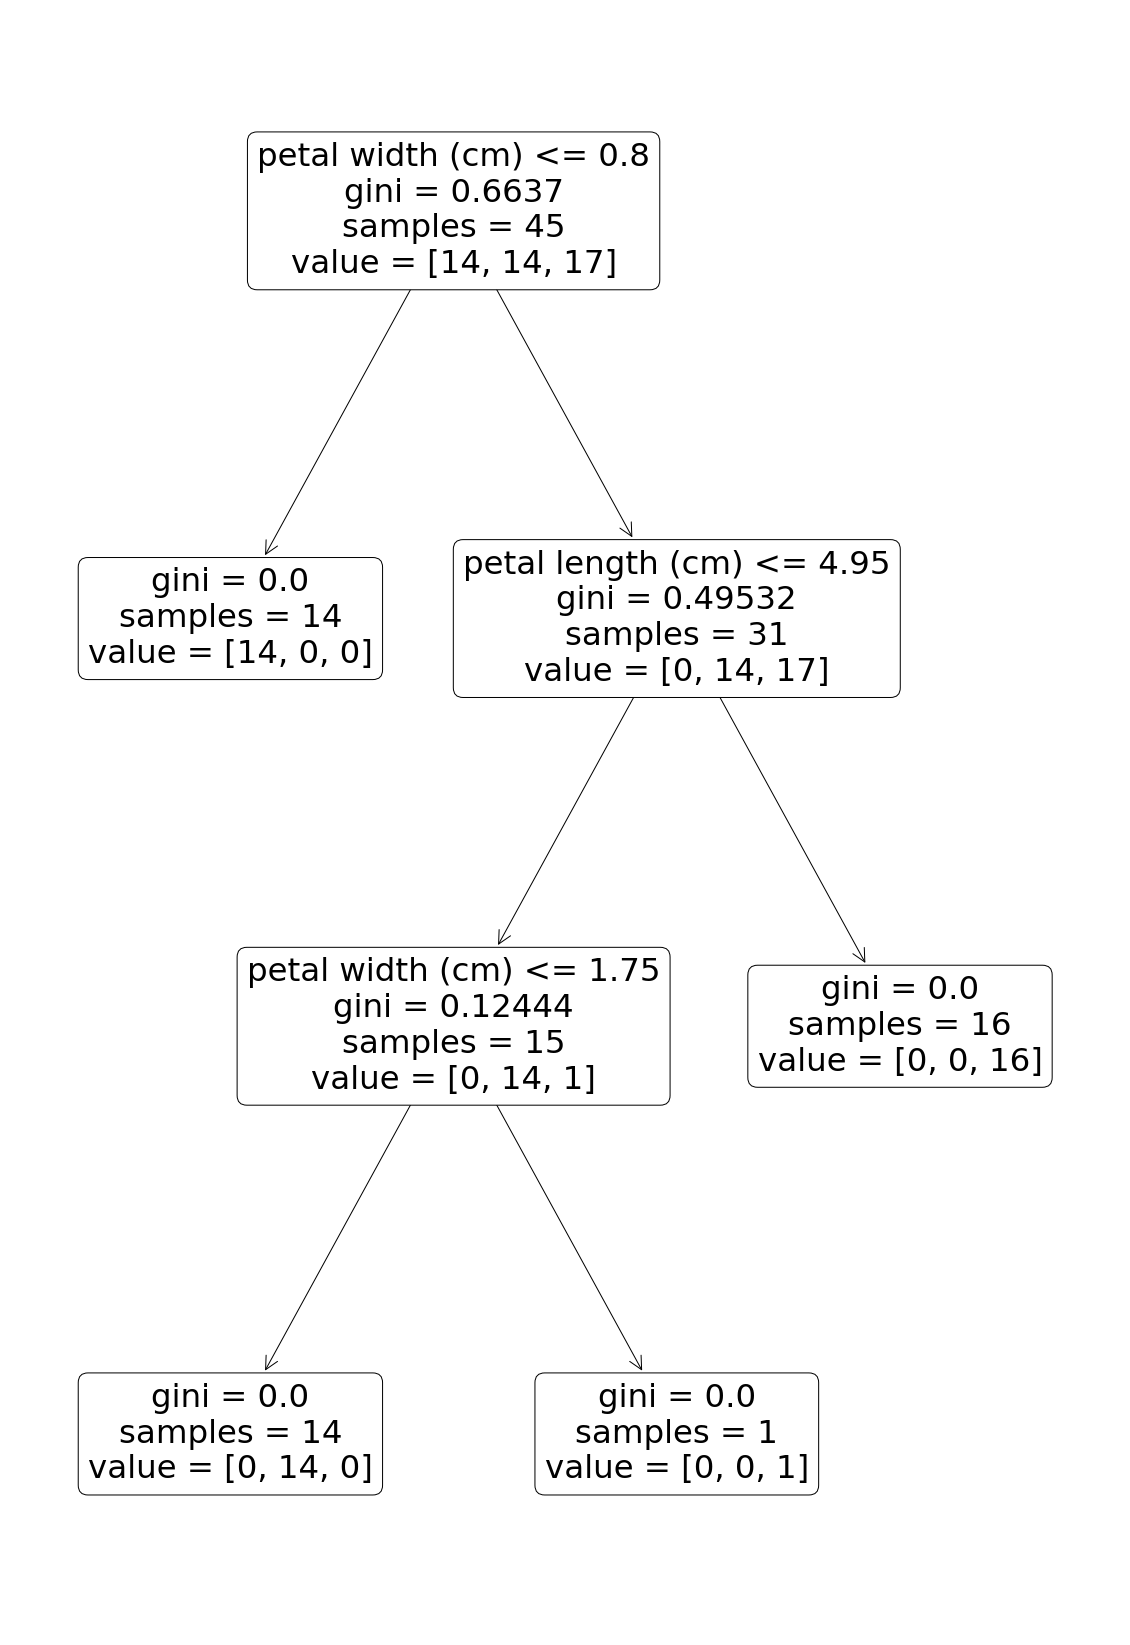

# Options for creating ensembles of decision trees

* #1 - Use different training sets via bootstrapping
* #2 - Randomly choose m predictors out of the total p predictors at each split

Combination of the two? **Random Forests**

# Random Forests

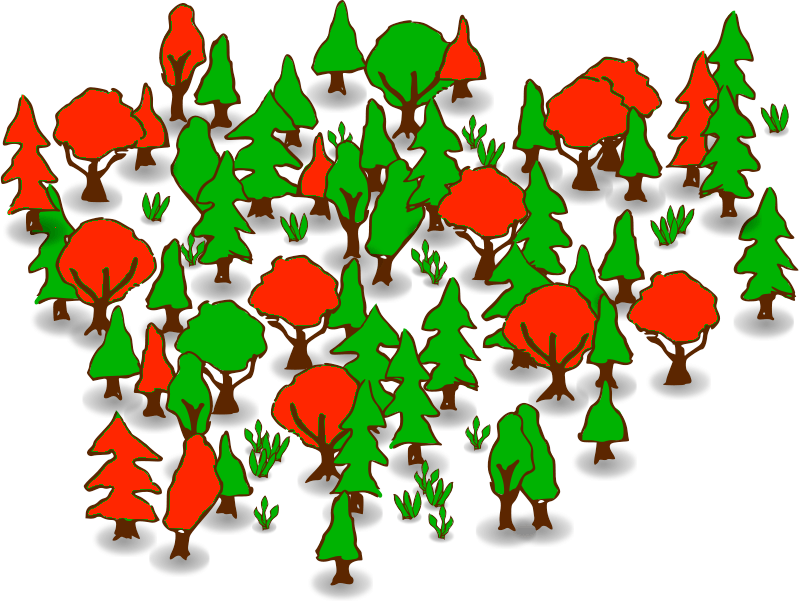

In [ ]:
#Define the statistical method we want to use
clf = sklearn.tree.DecisionTreeClassifier()
#Initialize the bagging object with the define based estimator and number of trees to use (n_estimators)
#Tell it to compute the out of bag estimate
bclf = sklearn.ensemble.RandomForestClassifier(n_estimators=100,oob_score=True)
#Fit the bagging classifier
bclf.fit(X,y)
#Print out of bag estimate of accuracy
print(bclf.oob_score_)

In general, Random Forests will outperform Bagging. However, the biggest change happens when moving to an ensemble method.

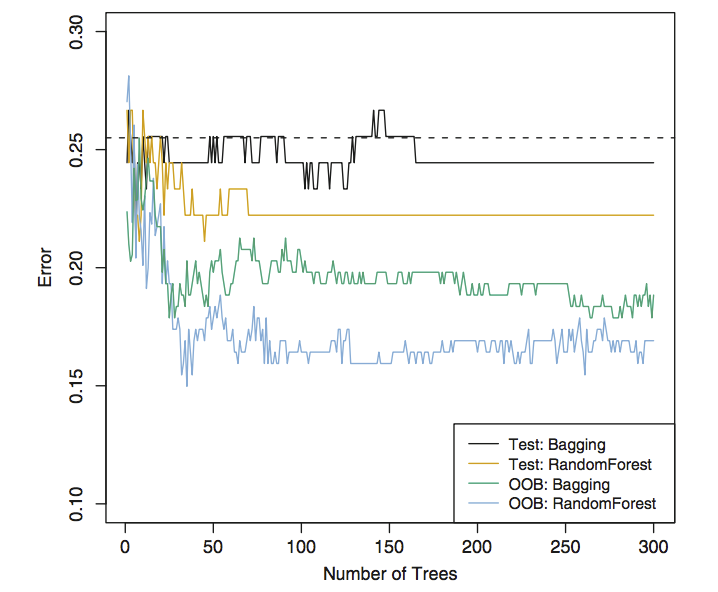

Source: G. James et al., An Introduction to Statistical Learning

# Feature importance (Bagging and Random Forests)

In [ ]:
#Define the statistical method we want to use
clf = sklearn.tree.DecisionTreeClassifier()
#Initialize the bagging object with the define based estimator and number of trees to use (n_estimators)
#Tell it to compute the out of bag estimate
bclf = sklearn.ensemble.RandomForestClassifier(n_estimators=100,oob_score=True)
#Fit the bagging classifier
bclf.fit(X,y)
#Print out of the feature importance per variable
print(bclf.feature_importances_)

# Let's go back to our example of Land Cover classification from the decision trees class

In [ ]:
#Read in all the data
import rasterio
%matplotlib inline
import matplotlib.pyplot as plt
vars = ['WELD_Band1_TOA_REF','WELD_Band2_TOA_REF','WELD_Band3_TOA_REF','WELD_Band4_TOA_REF',
        'WELD_Band5_TOA_REF','WELD_Band61_TOA_BT','WELD_Band62_TOA_BT','WELD_Band7_TOA_REF',
        'WELD_NDVI_TOA','nlcd_land_cover','nlcd_impervious','nlcd_tree_canopy']
data = {}
for var in vars:
    src = rasterio.open('../Workspace/%s.tif' % var)
    data[var] = src.read(1)
    src.close()

In [ ]:
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import numpy as np
src = rasterio.open("../Workspace/nlcd_land_cover.tif")
data['nlcd_land_cover'] = src.read(1)

# colormap determination and setting bounds
with rasterio.open("../Workspace/nlcd_land_cover.tif") as r:
    cmap_in = r.colormap(1)
    cmap1 = [[int(jj) for jj in cmap_in[ii]] for ii in cmap_in]
    cmap_in = [[float(jj)/255.0 for jj in cmap_in[ii]] for ii in cmap_in]
    indx_list = np.unique(data['nlcd_land_cover'])
    r_cmap = []    
    for ii in indx_list:
        r_cmap.append(cmap_in[ii])
    raster_cmap = ListedColormap(r_cmap) # defining the NLCD specific color map
    norm = mpl.colors.BoundaryNorm(indx_list, raster_cmap.N) # specifying colors based on num. unique points
    
plt.figure(figsize=(10,10))
plt.imshow(data['nlcd_land_cover'],cmap=raster_cmap,norm=norm)
plt.xticks([])
plt.yticks([])
plt.show()
src.close()

# Single decision tree

In [ ]:
import sklearn.tree 

variable = 'nlcd_land_cover' # target variable, think as our y variable
#Bring in the data
X = []
feature_names = []
# Lets flatten from 2D to 1D and store all the other variables in X
for var in data:
    if var == variable:
        continue
    tmp = data[var].reshape(data[var].size)
    X.append(tmp)
    feature_names.append(var)
X = np.array(X).T # transpose to have the right shape
#Define the target variable and flatten from 2D to 1D
Y = data[variable].reshape(data[variable].size)
#Draw 2500 samples to define the training dataset
np.random.seed(1)
idx = np.random.choice(Y.size,2500)
# create the boolean mask with the indices
m = np.zeros(Y.size).astype(int)
m[idx] = 1
m = m.astype(np.bool)
#Decision tree
clf = sklearn.tree.DecisionTreeClassifier()
#Fit the tree with the 2500 training samples
clf = clf.fit(X[m,:],Y[m])
#Assess the accuracy using the validation dataset (everything not in the training dataset ~m)
print('Accuracy:',clf.score(X[~m,:],Y[~m]))
#Predict the classes at each pixel
Ypred = clf.predict(X[~m,:])
#Make the figure to compare the original to the reproduced
plt.figure(figsize=(16,28))
plt.subplot(122)
plt.title('Reproduced - Decision Tree',fontsize=25)
plt.imshow(clf.predict(X).reshape(data['nlcd_land_cover'].shape),cmap=raster_cmap,norm=norm)
plt.xticks([])
plt.yticks([])
plt.subplot(121)
plt.title('Original',fontsize=25)
plt.imshow(data['nlcd_land_cover'],cmap=raster_cmap,norm=norm)
plt.xticks([])
plt.yticks([])
plt.show()

# Random Forest

In [ ]:
import sklearn.ensemble
#Random forest
clf = sklearn.ensemble.RandomForestClassifier(n_estimators=100)
#Fit the random forest with the 2500 training samples
clf = clf.fit(X[m,:],Y[m])
#Assess the accuracy using the validation dataset (everything not in the training dataset ~m)
print('Accuracy:',clf.score(X[~m,:],Y[~m]))
#Predict the classes at each pixel
Ypred = clf.predict(X[~m,:])
#Make the figure to compare the original to the reproduced
plt.figure(figsize=(16,28))
plt.subplot(122)
plt.title('Reproduced - Random Forest',fontsize=25)
plt.imshow(clf.predict(X).reshape(data['nlcd_land_cover'].shape), cmap=raster_cmap, norm=norm)
plt.xticks([])
plt.yticks([])
plt.subplot(121)
plt.title('Original',fontsize=25)
plt.imshow(data['nlcd_land_cover'],cmap=raster_cmap,norm=norm)
plt.xticks([])
plt.yticks([])
plt.show()

# Random Forest example: POLARIS soil series

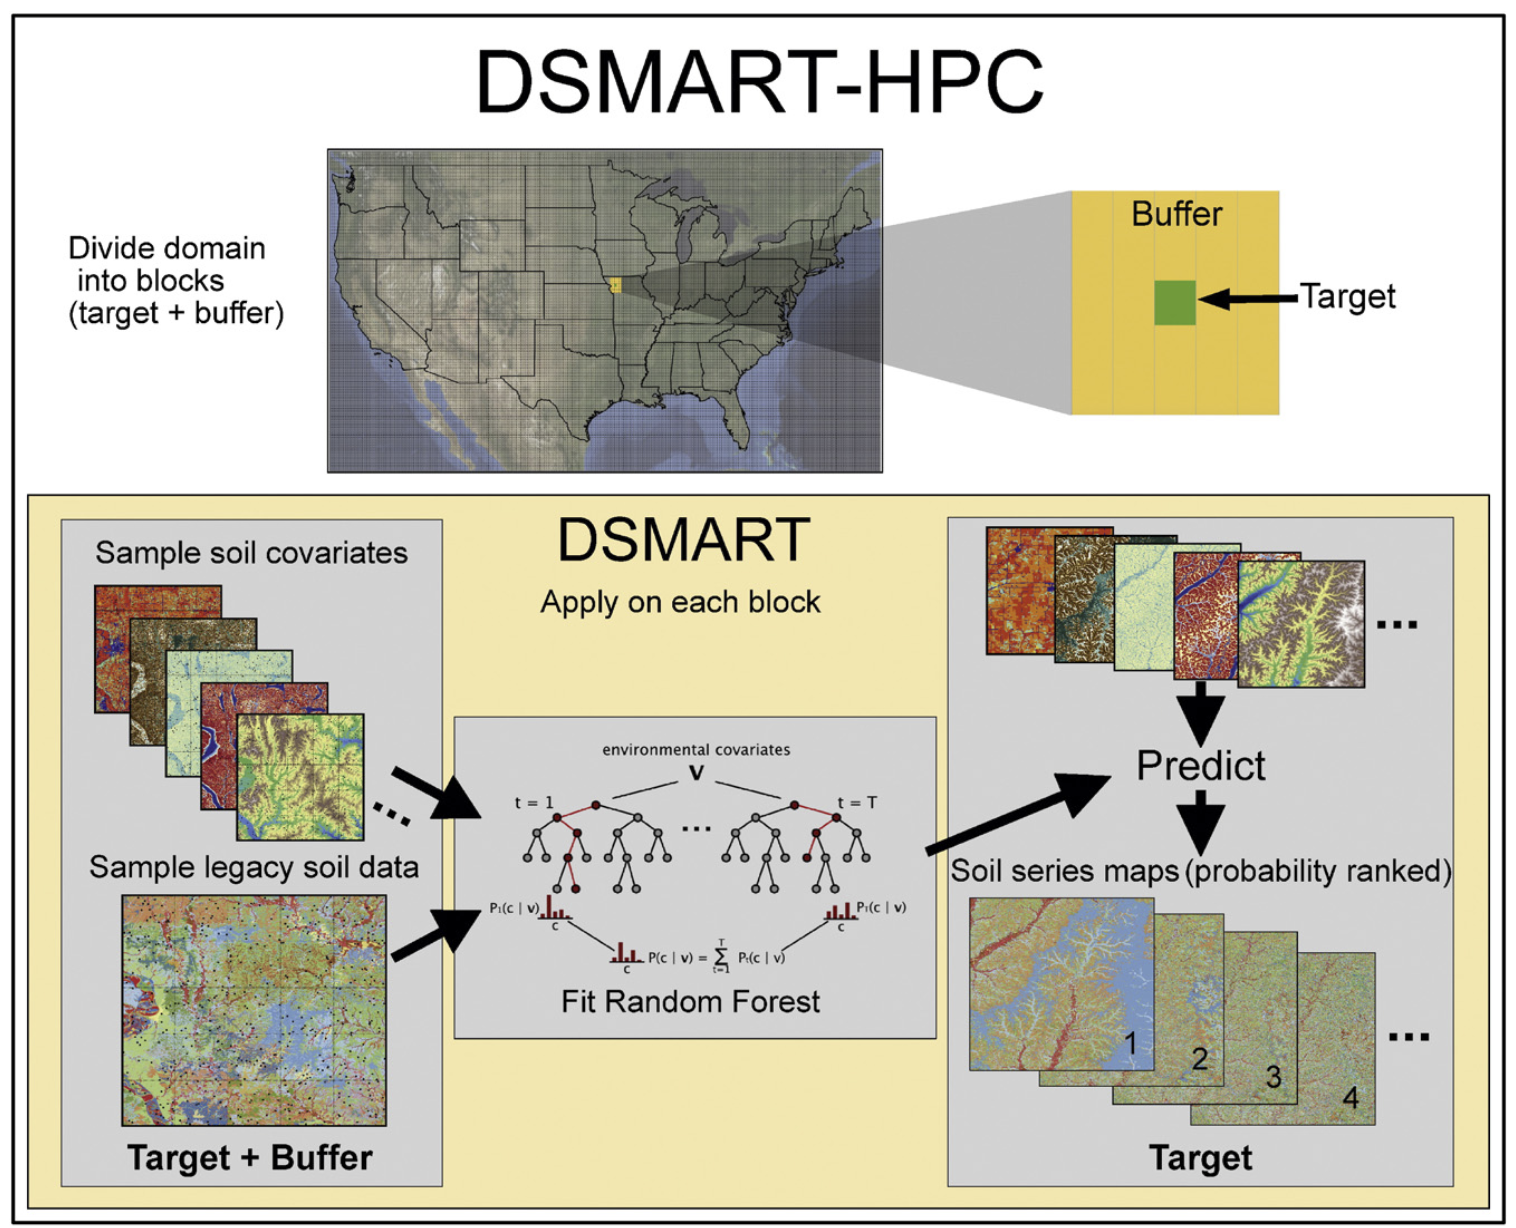

Chaney, N. W., E. F. Wood, J. W. Hempel, A. McBratney, T. Nauman, C. Brungard, N. Odgers, 2016: POLARIS: A 30-meter probabilistic soil series map of the contiguous United States. Geoderma,  274, 54-67.

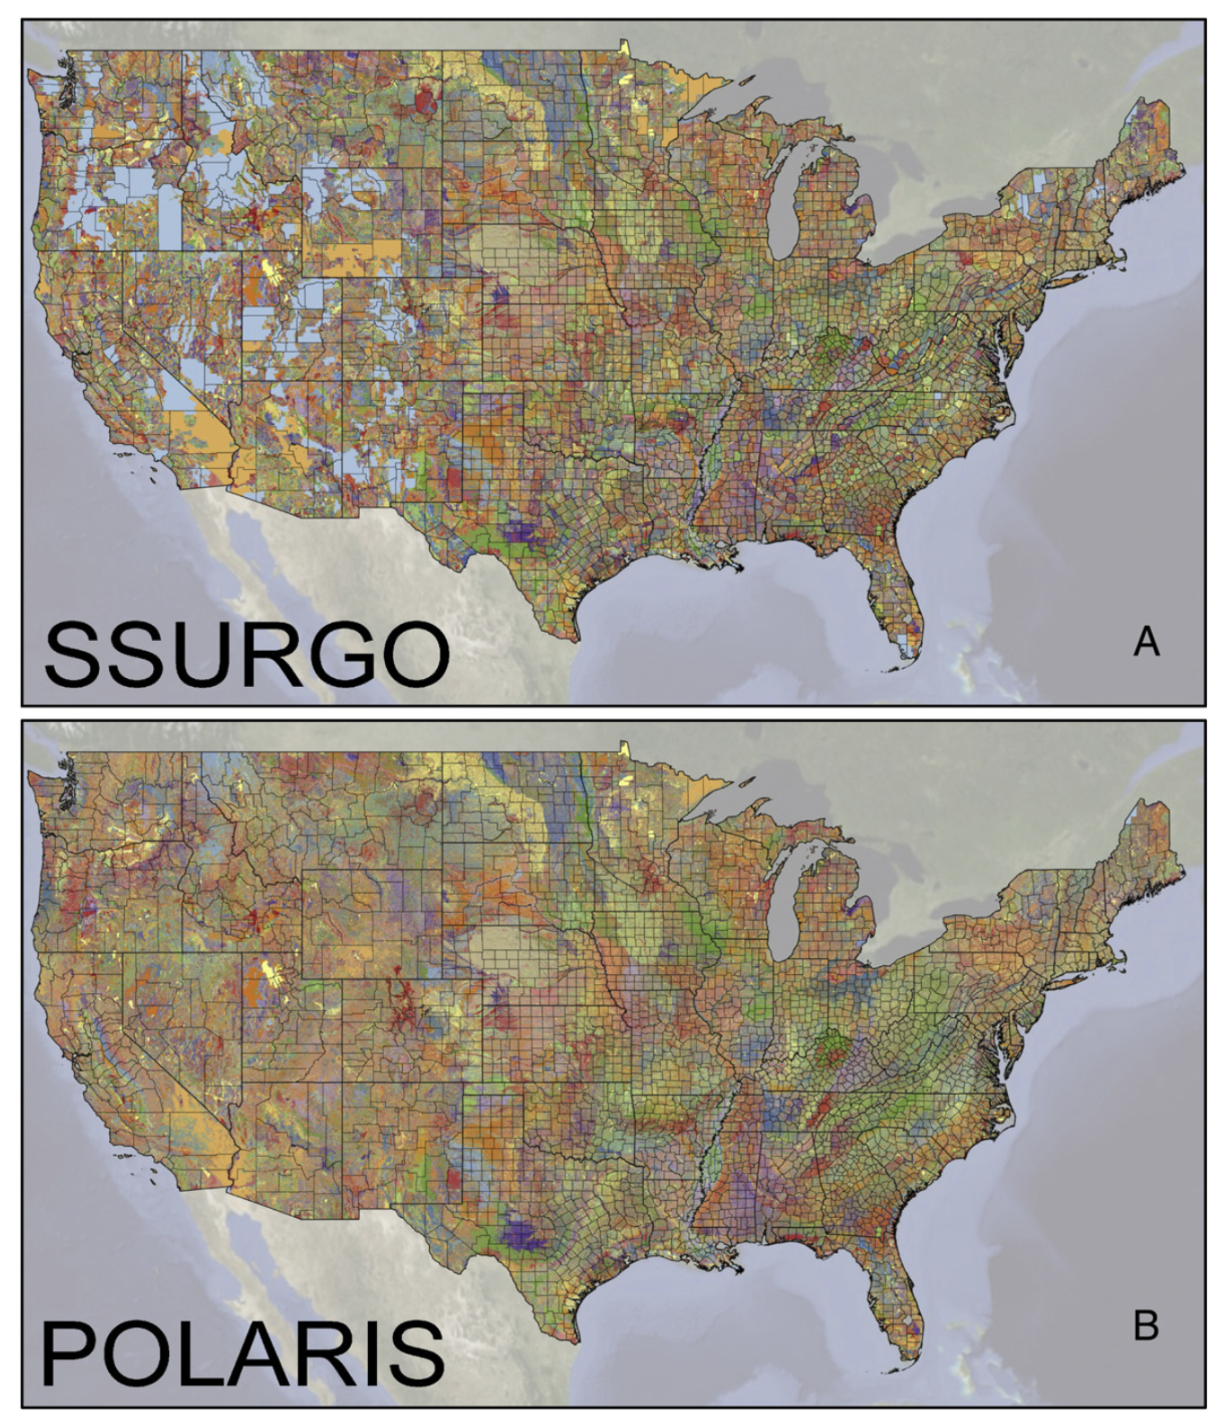

# POLARIS: Feature importance

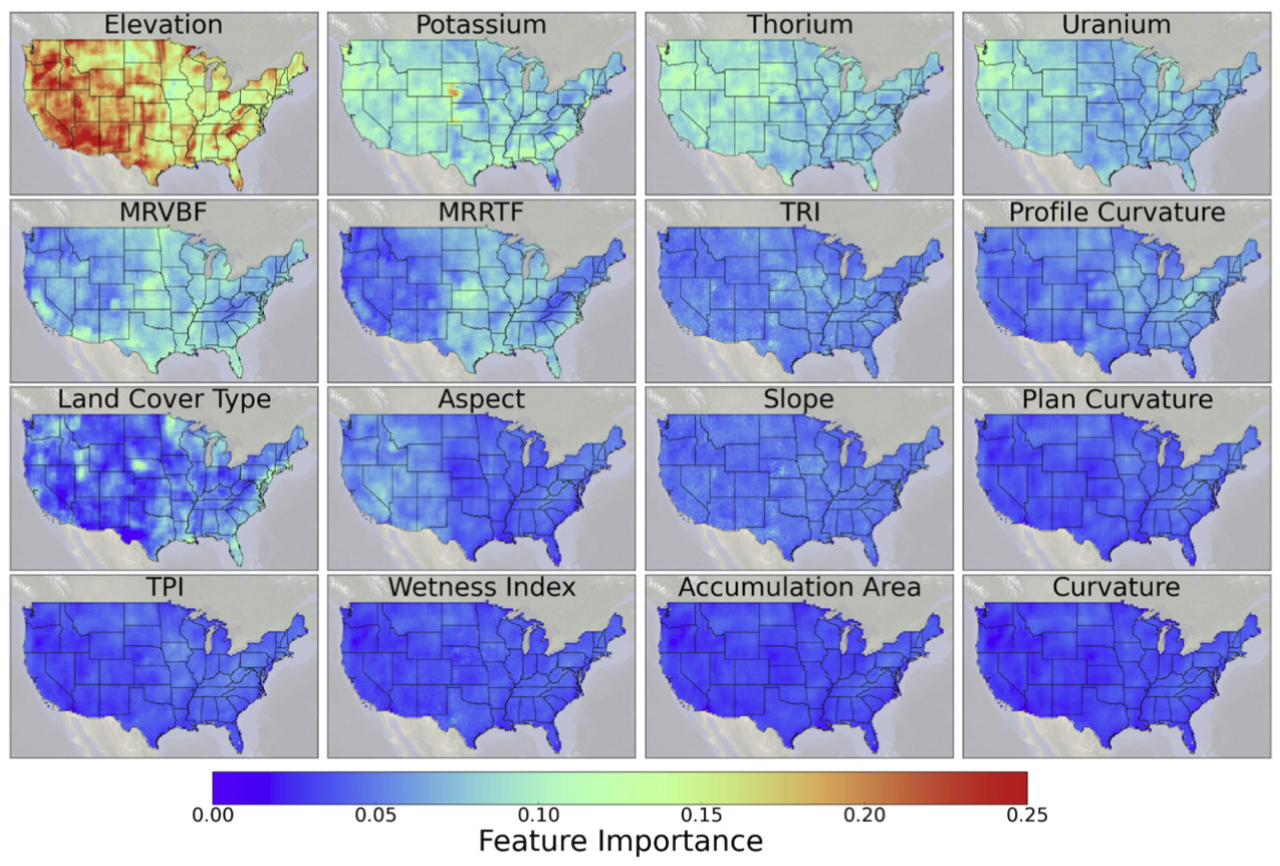

# POLARIS: Feature importance summary

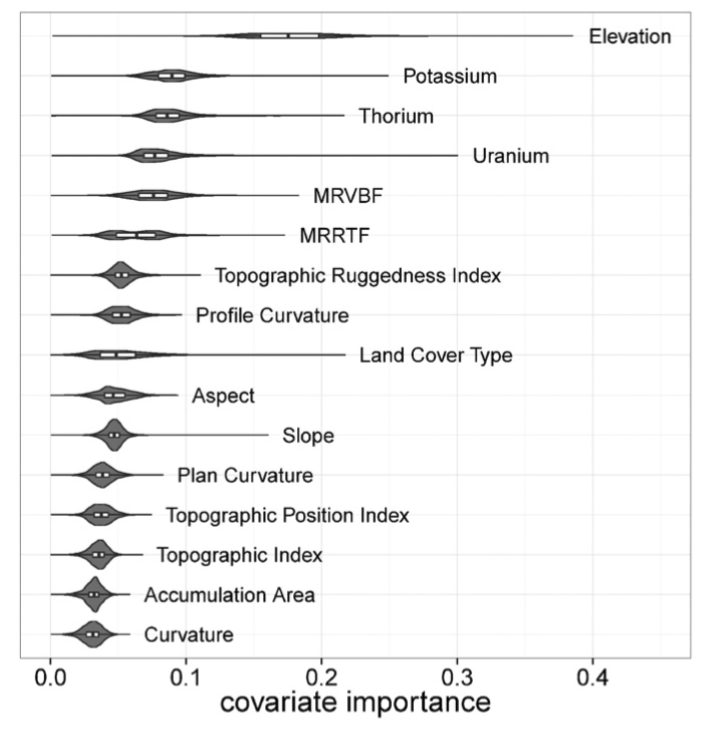

# Not just for classification

Random Forests and Bagging can also be used for regression problems